Step 1: Load Data

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics

# Load cleaned dataset
df = pd.read_csv('../data/processed/dataset.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

Shape: (14587, 22)

Columns: ['stop_id', 'route_id', 'route_short_name', 'trip_id', 'vehicle_id', 'snapshot_ts', 'gtfs_scheduled_ts', 'predicted_arrival_ts', 'delay_min', 'hour_of_day', 'day_of_week', 'is_weekend', 'is_peak_hour', 'month', 'date', 'hour_bucket', 'status', 'temperature_c', 'precipitation_mm', 'wind_speed_kmh', 'weather_code', 'is_raining']


,stop_id,route_id,route_short_name,trip_id,vehicle_id,snapshot_ts,gtfs_scheduled_ts,predicted_arrival_ts,delay_min,hour_of_day,...,is_peak_hour,month,date,hour_bucket,status,temperature_c,precipitation_mm,wind_speed_kmh,weather_code,is_raining
0,1_620,40_100239,550,40_561762249,40_9683,1773543148,1.773544e+09,1773543265,-6.58,20.0,...,0,3.0,2026-03-14,2026-03-14 20:00,default,5.8,0.0,6.9,3,0
1,1_25791,1_100214,372,1_609382219,1_7394,1773543148,1.773543e+09,1773543395,5.95,19.0,...,1,3.0,2026-03-14,2026-03-14 19:00,default,6.4,0.0,5.7,3,0
2,1_10210,1_100264,70,1_608612089,1_8244,1773543148,1.773543e+09,1773543290,-1.15,19.0,...,1,3.0,2026-03-14,2026-03-14 19:00,default,6.4,0.0,5.7,3,0
3,1_54201,1_102619,F Line,1_635423749,1_6279,1773543148,1.773543e+09,1773543284,7.25,19.0,...,1,3.0,2026-03-14,2026-03-14 19:00,default,6.4,0.0,5.7,3,0
4,1_40065,1_102574,40,1_778639929,1_8125,1773543148,1.773543e+09,1773543256,-2.55,19.0,...,1,3.0,2026-03-14,2026-03-14 19:00,default,6.4,0.0,5.7,3,0


Step 2: Feature Engineering

In [16]:
# Step 2: Feature Engineering

# Drop columns not useful for modeling
df = df.drop(columns=[
    'stop_id', 'route_id', 'route_short_name',  # categorical, too many unique values
    'trip_id', 'vehicle_id',                     # unique identifiers
    'snapshot_ts', 'gtfs_scheduled_ts',          # timestamps used to compute delay
    'predicted_arrival_ts',                      # timestamp
    'date', 'hour_bucket', 'month', 'status',    # redundant or no variation
])

# Model 1: Time features only (baseline)
features_time = ['hour_of_day', 'day_of_week', 'is_weekend', 'is_peak_hour']

# Model 2: Time + Rain (binary only)
# precipitation_mm excluded: threshold effect requires non-linear model
features_rain = ['hour_of_day', 'day_of_week', 'is_weekend', 'is_peak_hour',
                 'is_raining']

print("Model 1 features (time only):", features_time)
print("Model 2 features (time + rain binary):", features_rain)
print("\nTarget: delay_min")
print("Shape after cleaning:", df.shape)

Model 1 features (time only): ['hour_of_day', 'day_of_week', 'is_weekend', 'is_peak_hour']
Model 2 features (time + rain binary): ['hour_of_day', 'day_of_week', 'is_weekend', 'is_peak_hour', 'is_raining']

Target: delay_min
Shape after cleaning: (14587, 10)


Step 3: Model 1 — Time Features Only (Baseline)

In [17]:
# Step 3: Model 1 — Baseline (Time Features Only)
y = df['delay_min'].values

X1 = df[features_time].values
X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y, test_size=0.2, random_state=42)

lr1 = LinearRegression()
lr1.fit(X1_train, y1_train)
y1_pred = lr1.predict(X1_test)

r2_1   = metrics.r2_score(y1_test, y1_pred)
rmse_1 = np.sqrt(metrics.mean_squared_error(y1_test, y1_pred))
mae_1  = metrics.mean_absolute_error(y1_test, y1_pred)

print("=== Model 1: Baseline (Time Only) ===")
print(f"R²   : {r2_1:.4f}")
print(f"RMSE : {rmse_1:.4f} minutes")
print(f"MAE  : {mae_1:.4f} minutes")
print(f"\nCoefficients:")
for feat, coef in zip(features_time, lr1.coef_):
    print(f"  {feat:<20}: {coef:.4f}")

=== Model 1: Baseline (Time Only) ===
R²   : -0.0019
RMSE : 5.5999 minutes
MAE  : 3.3787 minutes

Coefficients:
  hour_of_day         : -0.0112
  day_of_week         : 0.0018
  is_weekend          : -0.6451
  is_peak_hour        : 0.0444


Step 4: Model 2 — Time + Rain Binary

In [18]:
# Step 4: Model 2 — Time + Rain Features
X2 = df[features_rain].values
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y, test_size=0.2, random_state=42)

lr2 = LinearRegression()
lr2.fit(X2_train, y2_train)
y2_pred = lr2.predict(X2_test)

r2_2   = metrics.r2_score(y2_test, y2_pred)
rmse_2 = np.sqrt(metrics.mean_squared_error(y2_test, y2_pred))
mae_2  = metrics.mean_absolute_error(y2_test, y2_pred)

print("=== Model 2: Time + Rain Binary ===")
print(f"R²   : {r2_2:.4f}")
print(f"RMSE : {rmse_2:.4f} minutes")
print(f"MAE  : {mae_2:.4f} minutes")
print(f"\nCoefficients:")
for feat, coef in zip(features_rain, lr2.coef_):
    print(f"  {feat:<20}: {coef:.4f}")

=== Model 2: Time + Rain Binary ===
R²   : -0.0026
RMSE : 5.6018 minutes
MAE  : 3.3831 minutes

Coefficients:
  hour_of_day         : -0.0201
  day_of_week         : -0.0515
  is_weekend          : -0.4406
  is_peak_hour        : 0.0764
  is_raining          : 0.3297


Step 5: Comparison & Conclusion

=== Model Comparison ===
Metric   Model 1 (Time Only)    Model 2 (+Rain Binary)   Δ (M1→M2)
----------------------------------------------------------------------
R²       -0.0019                -0.0026                  -0.0007
RMSE     5.5999                 5.6018                   +0.0019
MAE      3.3787                 3.3831                   +0.0044


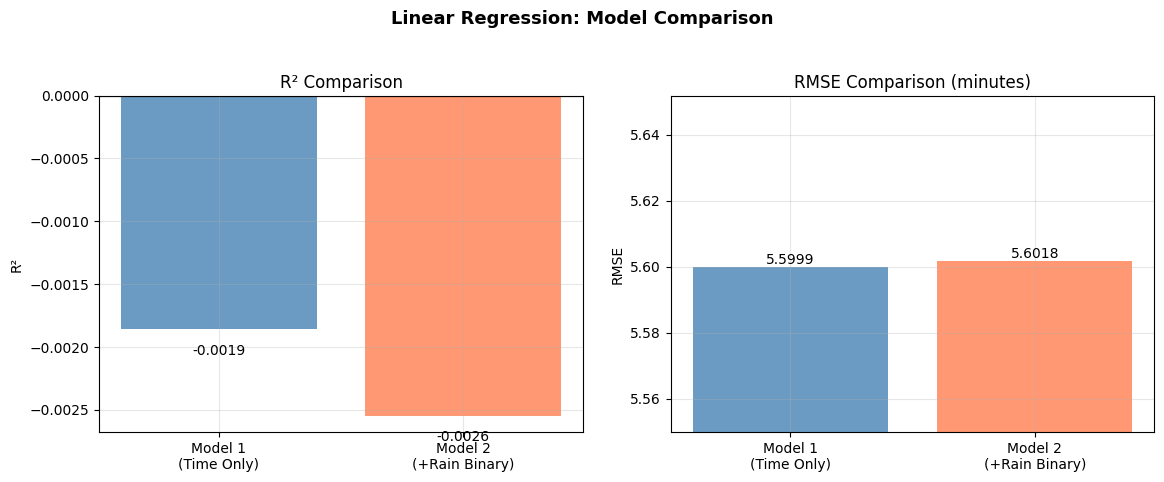


=== Conclusion ===

1. Both models have negative R² (-0.0019 and -0.0026), indicating that
   time and weather features cannot explain bus delay variance —
   the models perform worse than simply predicting the mean.

2. Adding rain binary (Model 2) over baseline (Model 1):
   - R² change : -0.0007 (slightly worse)
   - RMSE change: +0.0019 minutes (slightly worse)
   - Conclusion: is_raining has no meaningful linear impact on delays.

3. Most important predictor: is_weekend (coef ≈ -0.64)
   Buses arrive slightly earlier on weekends due to reduced traffic,
   but the effect is much weaker than previously observed.

4. precipitation_mm was intentionally excluded from linear regression:
   rainfall likely has a threshold effect (delays spike only above a
   certain intensity), which requires a non-linear model to capture.

5. Key answer to the core research question:
   Seattle rain does NOT meaningfully degrade bus schedule reliability
   in a way that linear regression can detect.

6

In [19]:
# Step 5: Model Comparison & Conclusion
print("=== Model Comparison ===")
print(f"{'Metric':<8} {'Model 1 (Time Only)':<22} {'Model 2 (+Rain Binary)':<24} {'Δ (M1→M2)'}")
print("-" * 70)
print(f"{'R²':<8} {r2_1:<22.4f} {r2_2:<24.4f} {r2_2-r2_1:+.4f}")
print(f"{'RMSE':<8} {rmse_1:<22.4f} {rmse_2:<24.4f} {rmse_2-rmse_1:+.4f}")
print(f"{'MAE':<8} {mae_1:<22.4f} {mae_2:<24.4f} {mae_2-mae_1:+.4f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
models = ['Model 1\n(Time Only)', 'Model 2\n(+Rain Binary)']
colors = ['steelblue', 'coral']

# R² comparison
axes[0].bar(models, [r2_1, r2_2], color=colors, alpha=0.8)
axes[0].set_title('R² Comparison')
axes[0].set_ylabel('R²')
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=0, color='black', linewidth=0.8)
for i, v in enumerate([r2_1, r2_2]):
    axes[0].text(i, v - 0.0002, f'{v:.4f}', ha='center', fontsize=10)

# RMSE comparison
rmse_min = min(rmse_1, rmse_2)
rmse_max = max(rmse_1, rmse_2)
axes[1].bar(models, [rmse_1, rmse_2], color=colors, alpha=0.8)
axes[1].set_title('RMSE Comparison (minutes)')
axes[1].set_ylabel('RMSE')
axes[1].set_ylim(rmse_min - 0.05, rmse_max + 0.05)
axes[1].grid(True, alpha=0.3)
for i, v in enumerate([rmse_1, rmse_2]):
    axes[1].text(i, v + 0.001, f'{v:.4f}', ha='center', fontsize=10)

plt.suptitle('Linear Regression: Model Comparison', fontsize=13, fontweight='bold')
plt.tight_layout(pad=2.0)
plt.show()

print("""
=== Conclusion ===

1. Both models have negative R² (-0.0019 and -0.0026), indicating that
   time and weather features cannot explain bus delay variance —
   the models perform worse than simply predicting the mean.

2. Adding rain binary (Model 2) over baseline (Model 1):
   - R² change : -0.0007 (slightly worse)
   - RMSE change: +0.0019 minutes (slightly worse)
   - Conclusion: is_raining has no meaningful linear impact on delays.

3. Most important predictor: is_weekend (coef ≈ -0.64)
   Buses arrive slightly earlier on weekends due to reduced traffic,
   but the effect is much weaker than previously observed.

4. precipitation_mm was intentionally excluded from linear regression:
   rainfall likely has a threshold effect (delays spike only above a
   certain intensity), which requires a non-linear model to capture.

5. Key answer to the core research question:
   Seattle rain does NOT meaningfully degrade bus schedule reliability
   in a way that linear regression can detect.

6. Next steps:
   - Address negative delay issue (schedule padding) before next model
   - Random Forest / XGBoost: handle non-linearity, threshold effects,
     and route-level features via target encoding
   - Include route_id with target encoding to capture route-specific
     delay patterns
""")